# Employee Dataset — Data Cleaning, Analysis & Visualisation
**Dataset:** `messy_dataset_Mukesh.csv`  
**Tasks:** Load → Clean → Analyse → Visualise → Correlate → Detect Outliers

---
## Task 1: Load & Inspect the Dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

df_raw = pd.read_csv('messy_dataset_Mukesh.csv')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
df_raw

Shape: 10 rows x 6 columns


,ID,Name,Age,Country,Salary,Join Date
0,1.0,Alice,25,NZ,55000,15/01/2020
1,2.0,Bob,NaN,NZ,60000,20/02/2020
2,2.0,Bob,30,NZ,NaN,20/02/2020
3,4.0,Charlie,35,AUS,72000,NaN
4,5.0,David,thirty-eight,NZ,68000,1/11/2019
5,NaN,Eve,29,AU,59000,2019-13-01
6,7.0,NaN,40,NZ,sixty five thousand,30/05/2018
7,8.0,Grace,22,NaN,64000,25/07/2021
8,9.0,Heidi,NaN,AUS,NaN,25/07/2021
9,10.0,Ivan,27,NZ,58000,15/03/2019


In [26]:
# Column data types
print('--- Data Types ---')
print(df_raw.dtypes)
print('\n--- Missing Values ---')
print(df_raw.isnull().sum())

--- Data Types ---
ID           float64
Name          object
Age           object
Country       object
Salary        object
Join Date     object
dtype: object

--- Missing Values ---
ID           1
Name         1
Age          2
Country      1
Salary       2
Join Date    1
dtype: int64


---
## Task 2: Data Cleaning

### Issues found in the raw data:
| Issue | Detail |
|---|---|
| Duplicate row | Bob (ID=2) appears twice with different missing fields |
| Missing ID | Eve has no ID |
| Missing Name | Row 7 has no name |
| Text in numeric column | Age: `thirty-eight`, Salary: `sixty five thousand` |
| Invalid date | `2019-13-01` — month 13 does not exist |
| Inconsistent country codes | `AU` and `AUS` used for same country |
| Missing Age | Bob (row 1), Heidi |
| Missing Salary | Bob (row 2), Heidi |
| Missing Country | Grace |
| Missing Join Date | Charlie |

In [27]:
df = df_raw.copy()

# 1. Fix Age -- convert word to number, then cast to numeric
df['Age'] = df['Age'].replace({'thirty-eight': 38})
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 2. Fix Salary -- convert word to number, then cast to numeric
df['Salary'] = df['Salary'].replace({'sixty five thousand': 65000})
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

# 3. Fix Join Date -- handle multiple date formats
def parse_date(d):
    if pd.isna(d): return pd.NaT
    for fmt in ('%d/%m/%Y', '%Y-%m-%d', '%Y-%d-%m'):  # added %Y-%d-%m as fallback
        try: return pd.to_datetime(d, format=fmt)
        except: pass
    return pd.NaT # returns NaT for unparseable dates

df['Join Date'] = df['Join Date'].apply(parse_date)

# 4. Standardise country codes: AU -> AUS
df['Country'] = df['Country'].replace({'AU': 'AUS'})

print('After type fixes:')
print(df.dtypes)
print('\nMissing values now:')
print(df.isnull().sum())

After type fixes:
ID                  float64
Name                 object
Age                 float64
Country              object
Salary              float64
Join Date    datetime64[ns]
dtype: object

Missing values now:
ID           1
Name         1
Age          2
Country      1
Salary       2
Join Date    1
dtype: int64


In [28]:
# 5. Fill missing ID -- Eve gets ID 6
existing_ids = set(df['ID'].dropna().astype(int))

def find_gap_for_row(idx):
    # Look at the IDs immediately before and after this row
    prev_id = df.loc[:idx-1, 'ID'].dropna()
    next_id = df.loc[idx+1:, 'ID'].dropna()

    prev = int(prev_id.iloc[-1]) if not prev_id.empty else 0
    nxt  = int(next_id.iloc[0])  if not next_id.empty else prev + 1

    # Find the first gap between prev and next that isn't taken
    for candidate in range(prev + 1, nxt):
        if candidate not in existing_ids:
            existing_ids.add(candidate)
            return candidate

    # If no gap between neighbours, use next available after max
    candidate = max(existing_ids) + 1
    existing_ids.add(candidate)
    return candidate

missing_mask = df['ID'].isna()
df.loc[missing_mask, 'ID'] = df[missing_mask].index.map(find_gap_for_row)
df['ID'] = df['ID'].astype(int)

# 6. Fill missing Name -- assign placeholder
df.loc[df['Name'].isna(), 'Name'] = 'Unknown'

# 7. Fill missing Age with median (robust to skew)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 8. Fill missing Salary with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# 9. Fill missing Country with mode (most frequent)
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

# 10. Fill missing Join Date with forward fill (carry previous date forward)
df['Join Date'] = df['Join Date'].ffill()

# 11. Remove duplicate rows -- Bob appears twice; keep first occurrence
df = df.drop_duplicates(subset=['ID', 'Name'], keep='first').reset_index(drop=True)
df['ID'] = df['ID'].astype(int)

print('Final cleaned dataset:')
df

Final cleaned dataset:


,ID,Name,Age,Country,Salary,Join Date
0,1,Alice,25.0,NZ,55000.0,2020-01-15
1,2,Bob,29.5,NZ,60000.0,2020-02-20
2,4,Charlie,35.0,AUS,72000.0,2020-02-20
3,5,David,38.0,NZ,68000.0,2019-11-01
4,6,Eve,29.0,AUS,59000.0,2019-01-13
5,7,Unknown,40.0,NZ,65000.0,2018-05-30
6,8,Grace,22.0,NZ,64000.0,2021-07-25
7,9,Heidi,29.5,AUS,62000.0,2021-07-25
8,10,Ivan,27.0,NZ,58000.0,2019-03-15


---
## Task 3: Basic Statistical Analysis

In [29]:
stats = pd.DataFrame({
    'Mean':    df[['Age','Salary']].mean().round(2),
    'Median':  df[['Age','Salary']].median().round(2),
    'Min':     df[['Age','Salary']].min().round(2),
    'Max':     df[['Age','Salary']].max().round(2),
    'Std Dev': df[['Age','Salary']].std().round(2),
})
print('Statistical Summary:')
stats

Statistical Summary:


,Mean,Median,Min,Max,Std Dev
Age,30.56,29.5,22.0,40.0,5.98
Salary,62555.56,62000.0,55000.0,72000.0,5294.13


---
## Task 4: Outlier Detection (IQR Method)

In [30]:
def detect_outliers_iqr(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{label}:')
    print(f'  Q1={Q1}, Q3={Q3}, IQR={IQR}')
    print(f'  Lower bound={lower:.2f}, Upper bound={upper:.2f}')
    print(f'  Outliers: {list(outliers) if not outliers.empty else "None detected"}')
    print()
    return lower, upper

age_lo, age_hi = detect_outliers_iqr(df['Age'], 'Age')
sal_lo, sal_hi = detect_outliers_iqr(df['Salary'], 'Salary')

Age:
  Q1=27.0, Q3=35.0, IQR=8.0
  Lower bound=15.00, Upper bound=47.00
  Outliers: None detected

Salary:
  Q1=59000.0, Q3=65000.0, IQR=6000.0
  Lower bound=50000.00, Upper bound=74000.00
  Outliers: None detected



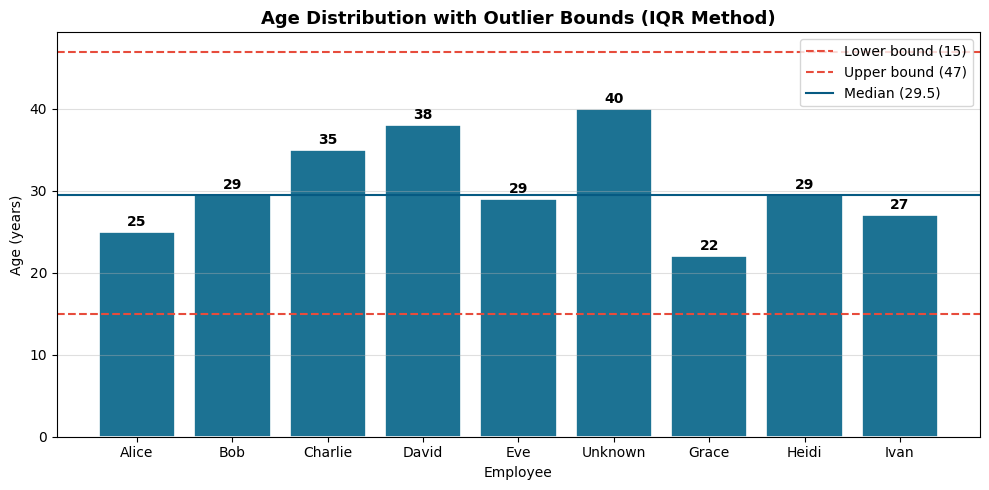

In [31]:
# Age bar chart with outlier bounds
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if (v < age_lo or v > age_hi) else '#1C7293' for v in df['Age']]
bars = ax.bar(df['Name'], df['Age'], color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(age_lo, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Lower bound ({age_lo:.0f})')
ax.axhline(age_hi, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Upper bound ({age_hi:.0f})')
ax.axhline(df['Age'].median(), color='#065A82', linestyle='-', linewidth=1.5,
           label=f"Median ({df['Age'].median():.1f})")
for bar, val in zip(bars, df['Age']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Age Distribution with Outlier Bounds (IQR Method)', fontsize=13, fontweight='bold')
ax.set_ylabel('Age (years)')
ax.set_xlabel('Employee')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

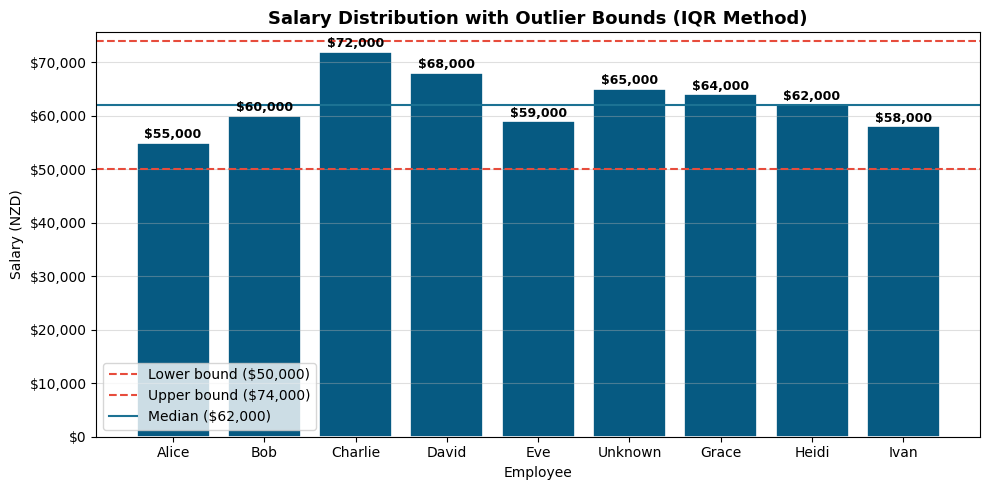

In [32]:
# Salary bar chart with outlier bounds
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if (v < sal_lo or v > sal_hi) else '#065A82' for v in df['Salary']]
bars = ax.bar(df['Name'], df['Salary'], color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(sal_lo, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Lower bound (${sal_lo:,.0f})')
ax.axhline(sal_hi, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Upper bound (${sal_hi:,.0f})')
ax.axhline(df['Salary'].median(), color='#1C7293', linestyle='-', linewidth=1.5,
           label=f"Median (${df['Salary'].median():,.0f})")
for bar, val in zip(bars, df['Salary']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Salary Distribution with Outlier Bounds (IQR Method)', fontsize=13, fontweight='bold')
ax.set_ylabel('Salary (NZD)')
ax.set_xlabel('Employee')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Task 5: Data Visualisation

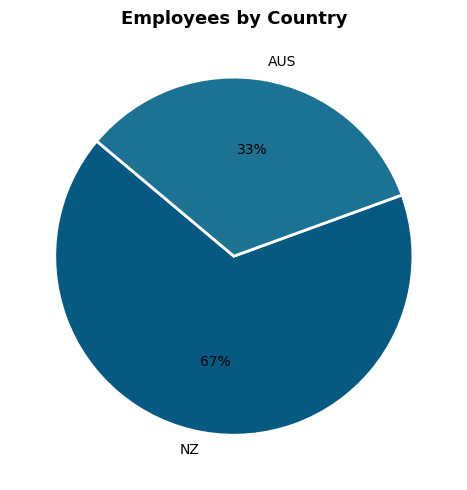

In [33]:
# Country breakdown pie chart
fig, ax = plt.subplots(figsize=(7, 5))
cc = df['Country'].value_counts()
ax.pie(cc, labels=cc.index, autopct='%1.0f%%', startangle=140,
       colors=['#065A82','#1C7293','#21295C'][:len(cc)],
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Employees by Country', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

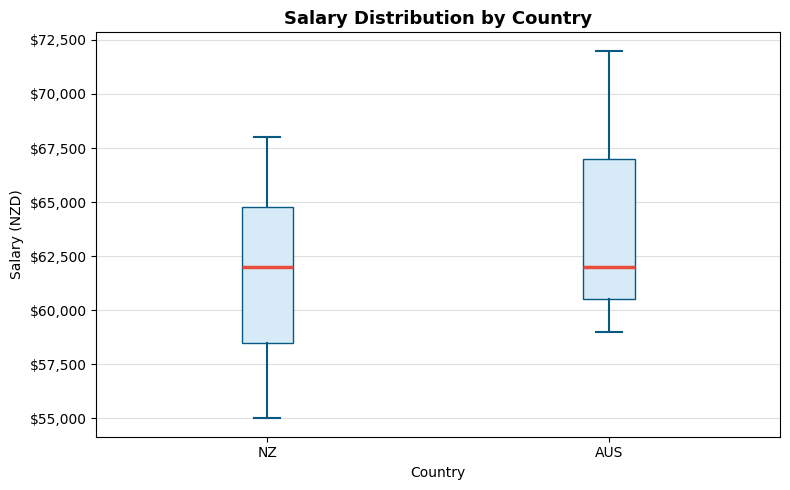

In [34]:
# Salary distribution by country -- boxplot
fig, ax = plt.subplots(figsize=(8, 5))
countries = df['Country'].unique()
groups = [df[df['Country'] == c]['Salary'].values for c in countries]
ax.boxplot(groups, tick_labels=countries, patch_artist=True,
           medianprops=dict(color='#E74C3C', linewidth=2.5),
           boxprops=dict(facecolor='#D6EAF8', color='#065A82'),
           whiskerprops=dict(color='#065A82', linewidth=1.5),
           capprops=dict(color='#065A82', linewidth=1.5))
ax.set_title('Salary Distribution by Country', fontsize=13, fontweight='bold')
ax.set_ylabel('Salary (NZD)')
ax.set_xlabel('Country')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Task 6: Pearson Correlation Analysis

In [35]:
df_enc = df.copy()

corr_cols = ['Age', 'Salary']

# corr_cols = ['Age', 'Salary', 'Country_Code', 'Join_Year']
# corr_matrix = df_enc[corr_cols].corr(method='pearson').round(2)
# corr_matrix.index = corr_matrix.columns = ['Age', 'Salary', 'Country', 'Join Year']

corr_matrix = df_enc[corr_cols].corr(method='pearson').round(2)
corr_matrix.index = corr_matrix.columns = ['Age', 'Salary']

print('Pearson Correlation Matrix:')
corr_matrix

Pearson Correlation Matrix:


,Age,Salary
Age,1.00,0.63
Salary,0.63,1.00


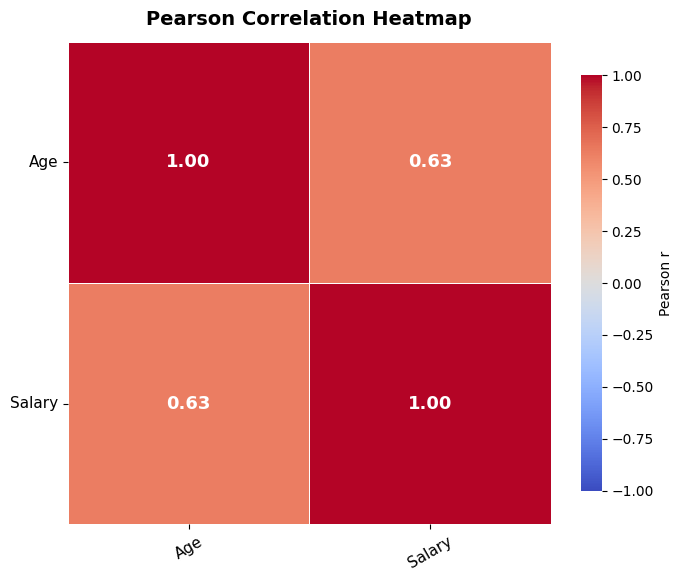

In [36]:
# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.6, linecolor='white', square=True,
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=11, rotation=30)
ax.tick_params(axis='y', labelsize=11, rotation=0)
plt.tight_layout()
plt.show()